˚. ✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.

# Stellar exploration through words: An interactive linguistic essay

Space, stars, and extraterrestrial travel are things commonly associated with progress, great courage, and adventures full of uncertainties. For example, moon landing, as Neil Armstrong said, was a "one small step for a man; one giant leap for mankind."  
Thus, this interactive essay aims to aid mankind by exploring the linguistic mystery of NASA web page. The goal of this work is to conduct simple linguistic analysis, including part-of-speech tagging and frequency analysis of text scraped from the previously mentioned page.

##Setup and library importing

The first step, crucial for further exploration, is setup preparation. It can be done by installing and importing essential libraries, such as **requests**, **BeautifulSoup**, **nltk**, **counter** from **collections**, **pandas**, **matplotlib.pyplot**, **seaborn**, and **wordcloud**. Requests are used for web scraping, BeautifulSoup for parisng, nltk for natural language processing, and counter for frequency counting. Pandas is used for easier data manipulation. The last set of libraries (matplotlib.pyplot, seaborn, and wordcloud) is used for visualisation and plotting.

In [1]:
!pip install wordcloud

In [2]:
import requests
from bs4 import BeautifulSoup
import nltk
from collections import Counter
import pandas as pd

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

##Web scraping and text extraction
The next stage includes web scraping and text extraction. First, a request was sent to `https://www.nasa.gov/` to retrieve the web page content. Secondly, the content was processed and parsed by BeautifulSoup to facilitate navigation and data extraction. Afterwards, all paragraphs were found and the text from these paragraphs was extracted. As the empty strings were filtered out, only meaningful text was retrieved `(only_text)`.



In [3]:
page = requests.get("https://www.nasa.gov/")
print(page.content)

b'<!doctype html>\n<html lang="en-US" prefix="og: https://ogp.me/ns#">\n<head>\n\t<meta charset="UTF-8">\n<script>\nvar gform;gform||(document.addEventListener("gform_main_scripts_loaded",function(){gform.scriptsLoaded=!0}),document.addEventListener("gform/theme/scripts_loaded",function(){gform.themeScriptsLoaded=!0}),window.addEventListener("DOMContentLoaded",function(){gform.domLoaded=!0}),gform={domLoaded:!1,scriptsLoaded:!1,themeScriptsLoaded:!1,isFormEditor:()=>"function"==typeof InitializeEditor,callIfLoaded:function(o){return!(!gform.domLoaded||!gform.scriptsLoaded||!gform.themeScriptsLoaded&&!gform.isFormEditor()||(gform.isFormEditor()&&console.warn("The use of gform.initializeOnLoaded() is deprecated in the form editor context and will be removed in Gravity Forms 3.1."),o(),0))},initializeOnLoaded:function(o){gform.callIfLoaded(o)||(document.addEventListener("gform_main_scripts_loaded",()=>{gform.scriptsLoaded=!0,gform.callIfLoaded(o)}),document.addEventListener("gform/theme/s

In [4]:
soup = BeautifulSoup(page.content, 'html.parser')

In [5]:
print(soup)

<!DOCTYPE html>

<html lang="en-US" prefix="og: https://ogp.me/ns#">
<head>
<meta charset="utf-8"/>
<script>
var gform;gform||(document.addEventListener("gform_main_scripts_loaded",function(){gform.scriptsLoaded=!0}),document.addEventListener("gform/theme/scripts_loaded",function(){gform.themeScriptsLoaded=!0}),window.addEventListener("DOMContentLoaded",function(){gform.domLoaded=!0}),gform={domLoaded:!1,scriptsLoaded:!1,themeScriptsLoaded:!1,isFormEditor:()=>"function"==typeof InitializeEditor,callIfLoaded:function(o){return!(!gform.domLoaded||!gform.scriptsLoaded||!gform.themeScriptsLoaded&&!gform.isFormEditor()||(gform.isFormEditor()&&console.warn("The use of gform.initializeOnLoaded() is deprecated in the form editor context and will be removed in Gravity Forms 3.1."),o(),0))},initializeOnLoaded:function(o){gform.callIfLoaded(o)||(document.addEventListener("gform_main_scripts_loaded",()=>{gform.scriptsLoaded=!0,gform.callIfLoaded(o)}),document.addEventListener("gform/theme/scripts_

In [6]:
paras = soup.find_all('p')

In [7]:
print(paras)

[<p class="maxw-tablet color-spacesuit-white">
										Meet the astronauts who will carry out a series of objectives in low Earth orbit to demonstrate critical systems needed for a future lunar landing, helping NASA and its partners reduce risk before Americans return to the Moon on Artemis IV.									</p>, <p class="heading-22 color-spacesuit-white margin-0"><span>NASA Marches Toward Artemis III Mission in 2027, Names Crew Members</span></p>, <p class="heading-22 color-spacesuit-white margin-0"><span>NASA’s X-59 Aircraft Flies Supersonic for First Time</span></p>, <p class="heading-22 color-spacesuit-white margin-0"><span>Crew Works Microbiology, Advanced Tech and Congratulates New Artemis III Crew</span></p>, <p class="heading-22 color-spacesuit-white margin-0"><span>Robotic Spacecraft for Swift Boost Mission Arrives at NASA Wallops</span></p>, <p class="heading-14 color-carbon-black line-height-md margin-top-1 margin-bottom-1">How NASA Science and Artemis Are Shaping the 2026 FIF

In [8]:
only_text = []
for el in paras:
    if len(el.getText().strip()) > 0:
        only_text.append(el.getText())
print(only_text)

['\n\t\t\t\t\t\t\t\t\t\tMeet the astronauts who will carry out a series of objectives in low Earth orbit to demonstrate critical systems needed for a future lunar landing, helping NASA and its partners reduce risk before Americans return to the Moon on Artemis IV.\t\t\t\t\t\t\t\t\t', 'NASA Marches Toward Artemis III Mission in 2027, Names Crew Members', 'NASA’s\xa0X-59\xa0Aircraft\xa0Flies Supersonic for First Time', 'Crew Works Microbiology, Advanced Tech and Congratulates New Artemis III Crew', 'Robotic Spacecraft for Swift Boost Mission Arrives at NASA Wallops', 'How NASA Science and\xa0Artemis Are Shaping the 2026 FIFA World Cup\xa0', 'NASA Satellites Reveal Aquifer Decline in Brazilian Breadbasket', 'NASA Concludes Antenna Mishap Investigation, Releases Report', 'What’s Up: June 2026 Skywatching Tips from NASA', 'Since NASA’s Artemis II crew safely splashed down in the Pacific Ocean on April 10 after their record-setting mission around the Moon, science teams have been busy collec

##POS tagging and frequency analysis
The following stage focused on part-of-speech tagging and frequency analysis of POS tags. NLTK resources were downloaded to enable tokenization and POS tagging. These resources are able to identify words and to assign grammatical categories to them. Sentences present in `only_text` were tokenized, and each word was given a POS tag, which was stored in a list. This list is called tuples and includes pairs consisting of the word and its tag. Then, each occurrence of a POS tag was counted to facilitate the identification of the most and least frequent POS tags.

In [9]:
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
tuples = []
for sentence in only_text:
    tokenized = nltk.word_tokenize(sentence)
    tagged = nltk.pos_tag(tokenized)
    for item in tagged:
        tuples.append(item)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [10]:
print(tuples)

[('Meet', 'NNP'), ('the', 'DT'), ('astronauts', 'NNS'), ('who', 'WP'), ('will', 'MD'), ('carry', 'VB'), ('out', 'RP'), ('a', 'DT'), ('series', 'NN'), ('of', 'IN'), ('objectives', 'NNS'), ('in', 'IN'), ('low', 'JJ'), ('Earth', 'NNP'), ('orbit', 'NN'), ('to', 'TO'), ('demonstrate', 'VB'), ('critical', 'JJ'), ('systems', 'NNS'), ('needed', 'VBN'), ('for', 'IN'), ('a', 'DT'), ('future', 'JJ'), ('lunar', 'NN'), ('landing', 'NN'), (',', ','), ('helping', 'VBG'), ('NASA', 'NNP'), ('and', 'CC'), ('its', 'PRP$'), ('partners', 'NNS'), ('reduce', 'VB'), ('risk', 'NN'), ('before', 'IN'), ('Americans', 'NNPS'), ('return', 'VBP'), ('to', 'TO'), ('the', 'DT'), ('Moon', 'NNP'), ('on', 'IN'), ('Artemis', 'NNP'), ('IV', 'NNP'), ('.', '.'), ('NASA', 'NNP'), ('Marches', 'NNP'), ('Toward', 'NNP'), ('Artemis', 'NNP'), ('III', 'NNP'), ('Mission', 'NNP'), ('in', 'IN'), ('2027', 'CD'), (',', ','), ('Names', 'NNP'), ('Crew', 'NNP'), ('Members', 'NNS'), ('NASA', 'NNP'), ('’', 'NNP'), ('s', 'VBD'), ('X-59', 'NNP'

In [11]:
counter_dict = {}
for item in tuples:
    if item[1] not in counter_dict:
        counter_dict[item[1]] = 1
    else:
        counter_dict[item[1]] += 1

print(counter_dict)

{'NNP': 111, 'DT': 25, 'NNS': 17, 'WP': 2, 'MD': 4, 'VB': 6, 'RP': 2, 'NN': 45, 'IN': 39, 'JJ': 20, 'TO': 6, 'VBN': 5, ',': 22, 'VBG': 8, 'CC': 15, 'PRP$': 8, 'NNPS': 2, 'VBP': 4, '.': 10, 'CD': 8, 'VBD': 7, 'VBZ': 9, 'WRB': 3, ':': 4, 'RB': 3, 'JJR': 1, '(': 1, ')': 1, 'JJS': 2, 'PRP': 1}


In [12]:
max_tag = max(counter_dict, key=counter_dict.get)
print(f"The most frequent POS tag is '{max_tag}' with a count of {counter_dict[max_tag]}.")
min_tag = min(counter_dict, key=counter_dict.get)
print(f"The least frequent POS tag is '{min_tag}' with a count of {counter_dict[min_tag]}.")

The most frequent POS tag is 'NNP' with a count of 111.
The least frequent POS tag is 'JJR' with a count of 1.


##Data visualization
The subsequent step involves a visualization of the most frequent part-of-speech tags. To enable such visualization, POS tags were converted into a pandas DataFrame, which is sorted by frequency, and the 10 most frequent tags were selected. Additionally, there were punctuation marks present among the most frequent results. The description of these tags is as follows:
- **NNP**: Proper noun, singular,
- **IN**: Preposition or subordinating conjunction,
- **DT**: Determiner,
- **JJ**: Adjective,
- **CC**: Coordinating conjunction,
- **VBZ**: Verb, 3rd person singular present.

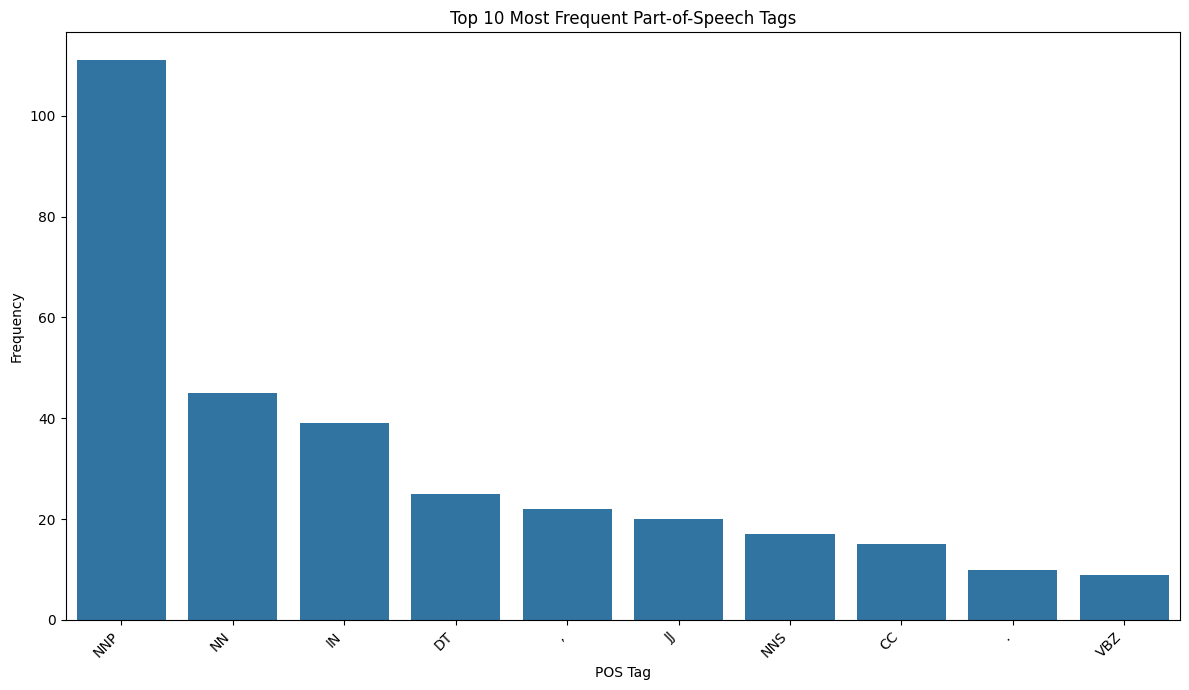

In [13]:
pos_df = pd.DataFrame(counter_dict.items(), columns=['POS_Tag', 'Frequency'])
pos_df = pos_df.sort_values(by='Frequency', ascending=False)
top_10_pos_df = pos_df.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='POS_Tag', y='Frequency', data=top_10_pos_df)
plt.title('Top 10 Most Frequent Part-of-Speech Tags')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
print(top_10_pos_df)

   POS_Tag  Frequency
0      NNP        111
7       NN         45
8       IN         39
1       DT         25
12       ,         22
9       JJ         20
2      NNS         17
14      CC         15
18       .         10
21     VBZ          9


##Detailed analysis of common nouns, adjectives, and verbs
Further, detailed analysis of specific POS tags was conducted. Proper nouns were extracted, their frequencies were counted, and the 10 most common proper nouns were printed. The same steps were applied to analyse adjectives and verbs, including their different forms. Moreover, a list of unique adjectives was also displayed. Unfortunately, the results sometimes include punctuation marks and possessive ‘s.

In [15]:
nnp_words = [word for word, tag in tuples if tag == 'NNP']
nnp_counts = Counter(nnp_words)

print("Most common Proper Nouns (NNP):")
for word, count in nnp_counts.most_common(10):
    print(f"{word}: {count}")

Most common Proper Nouns (NNP):
NASA: 16
Artemis: 7
Moon: 4
III: 4
Crew: 4
’: 3
Earth: 2
Mission: 2
June: 2
Meet: 1


In [16]:
adj_words = [word for word, tag in tuples if tag in ['JJ', 'JJR', 'JJS']]
adj_counts = Counter(adj_words)

print("Most common Adjectives (JJ, JJR, JJS):")
for word, count in adj_counts.most_common(10):
    print(f"{word}: {count}")

Most common Adjectives (JJ, JJR, JJS):
low: 1
critical: 1
future: 1
Robotic: 1
Brazilian: 1
s: 1
record-setting: 1
busy: 1
more: 1
astronaut: 1


In [17]:
adjectives = []
for word, tag in tuples:
    if tag in ['JJ', 'JJR', 'JJS']:
        adjectives.append(word)

# Print unique adjectives
unique_adjectives = sorted(list(set(adjectives)))
print("Unique Adjectives:")
for adj in unique_adjectives:
    print(adj)

Unique Adjectives:
Brazilian
European
Robotic
astronaut
busy
commercial
critical
earliest
first
future
human
latest
low
more
new
next
record-setting
rendezvous
s
scientific
semiquincentennial
unknown
up-to-date


In [18]:
verb_tags = ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ']
verb_words = [word for word, tag in tuples if tag in verb_tags]
verb_counts = Counter(verb_words)

print("Most common Verbs:")
for word, count in verb_counts.most_common(10):
    print(f"{word}: {count}")

Most common Verbs:
s: 3
astronaut: 3
demonstrate: 2
have: 2
carry: 1
needed: 1
helping: 1
reduce: 1
return: 1
Arrives: 1


## Word Cloud for Adjectives and Proper Nouns

Finally, the extracted adjectives and proper nouns were joined into their respective single strings. Then, word clouds were created from these strings. The words displayed on the adjective Word Cloud reveal the nature of NASA’s work and discoveries. They are related to exploration and innovation. Similarly, the proper noun Word Cloud reveals the area of NASA’s work. These words relate to missions, organizations, locations, and dates.

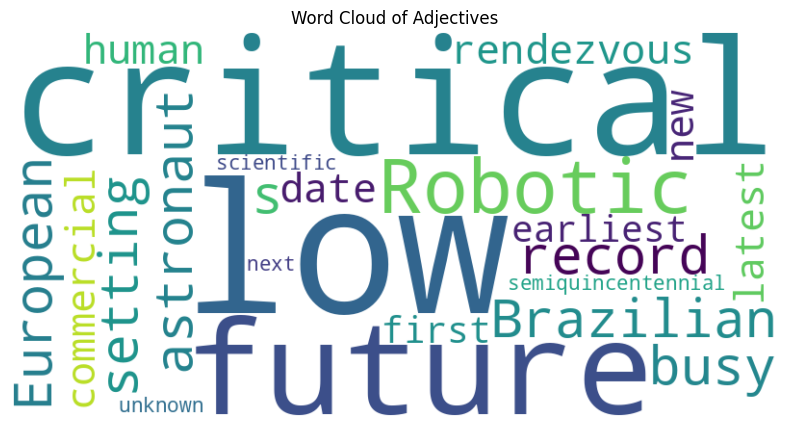

In [19]:
adj_text = " ".join(adj_words)
wordcloud_adj = WordCloud(width=800, height=400, background_color='white').generate(adj_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_adj, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Adjectives')
plt.show()

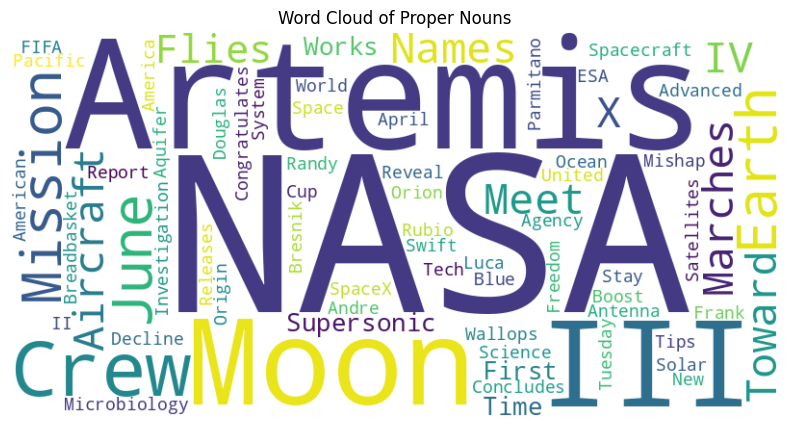

In [20]:
nnp_text = " ".join(nnp_words)

wordcloud_nnp = WordCloud(width=800, height=400, background_color='white').generate(nnp_text)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_nnp, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Proper Nouns')
plt.show()

##Conclusion
To conclude, this simple linguistic analysis was conducted on text scraped from NASA web page. It reveals the frequency of POS tags and the thematic areas connected with the scope of NASA’s missions.

˚. ✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.✦.˳·˖✶ ⋆.✧̣̇˚.
<img src = "https://www.nasa.gov/wp-content/uploads/2025/03/gsfc-20171208-archive-e000226orig.jpg" />